# 06 · Bivariate Analysis & Segmentation

**Goal:** Cross-variable analysis to surface headline findings and candidate stories.

Sections:
1. Setup & data load
2. Funding by college × year heatmap (detailed)
3. Agency × department funding matrix
4. Faculty rank × award size
5. Top-N faculty / departments by total $
6. Funding concentration — Gini coefficient & top-10 share
7. Candidate headline findings list

In [ ]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid', palette='muted')

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'data' / 'processed').exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
PROCESSED_DIR = REPO_ROOT / 'data' / 'processed'
OUTPUTS_DIR   = REPO_ROOT / 'outputs'
OUTPUTS_DIR.mkdir(exist_ok=True)

In [6]:
faculty       = pd.read_parquet(PROCESSED_DIR / 'faculty.parquet')
grants        = pd.read_parquet(PROCESSED_DIR / 'grants.parquet')
grant_faculty = pd.read_parquet(PROCESSED_DIR / 'grant_faculty.parquet')

# Merge grant_faculty with faculty and grants for enriched analysis
gf_full = (
    grant_faculty
    .merge(faculty[['employee id', 'superior_academic_unit',
                    'academic unit', 'academic rank', 'tenure status']],
           left_on='clientfacultyid', right_on='employee id', how='left')
    .merge(grants[['grantid', 'totaldollars', 'agencyname', 'agencycode',
                   'startdateyear']],
           on='grantid', how='left')
)

grants_yr = grants[(grants['startdateyear'] >= 2000) &
                   (grants['startdateyear'] <= 2025)].copy()

print(f'Enriched grant-faculty table: {gf_full.shape}')
print(f'Missing college after join: {gf_full["superior_academic_unit"].isna().sum():,}')

Enriched grant-faculty table: (3146, 14)
Missing college after join: 178


## 1 · Agency × Department Funding Matrix

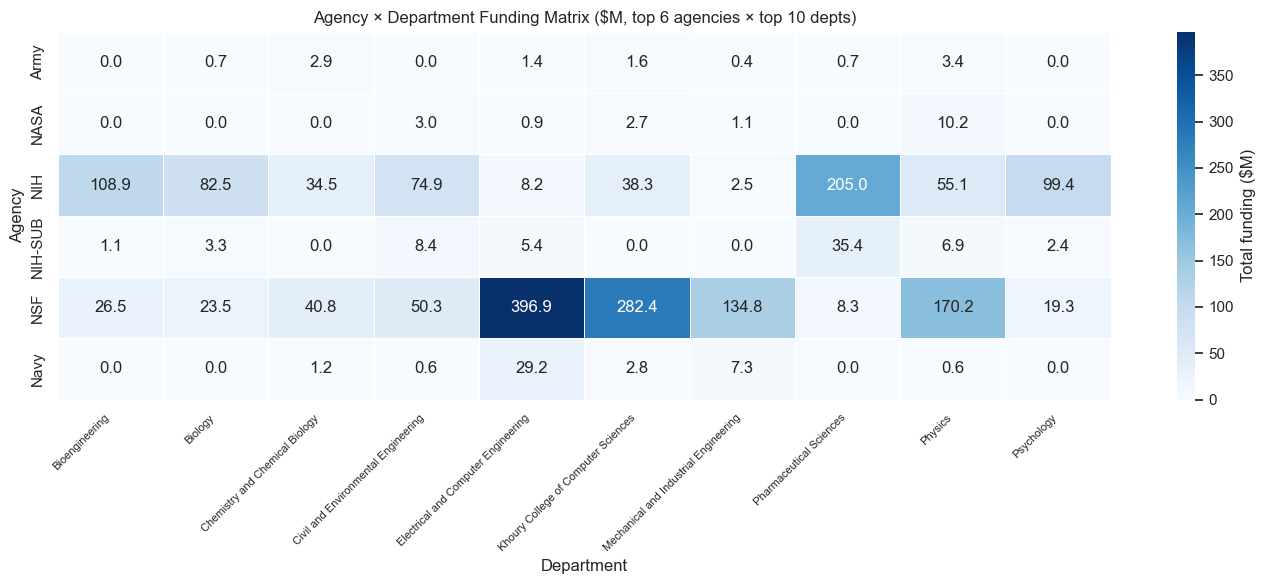

In [8]:
a_col = 'agencycode' if 'agencycode' in gf_full.columns else 'agencyname'
top_agencies = gf_full[a_col].value_counts().head(6).index.tolist()
top_depts = (gf_full.groupby('academic unit', observed=True)['totaldollars']
             .sum().sort_values(ascending=False).head(10).index.tolist())

matrix = (gf_full[
            gf_full[a_col].isin(top_agencies) &
            gf_full['academic unit'].isin(top_depts)]
          .groupby([a_col, 'academic unit'], observed=True)['totaldollars']
          .sum()
          .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(matrix / 1e6, annot=True, fmt='.1f', cmap='Blues', ax=ax,
            linewidths=0.4, cbar_kws={'label': 'Total funding ($M)'})
ax.set_title('Agency × Department Funding Matrix ($M, top 6 agencies × top 10 depts)')
ax.set_ylabel('Agency')
ax.set_xlabel('Department')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'w6_agency_dept_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 2 · Faculty Rank × Award Size

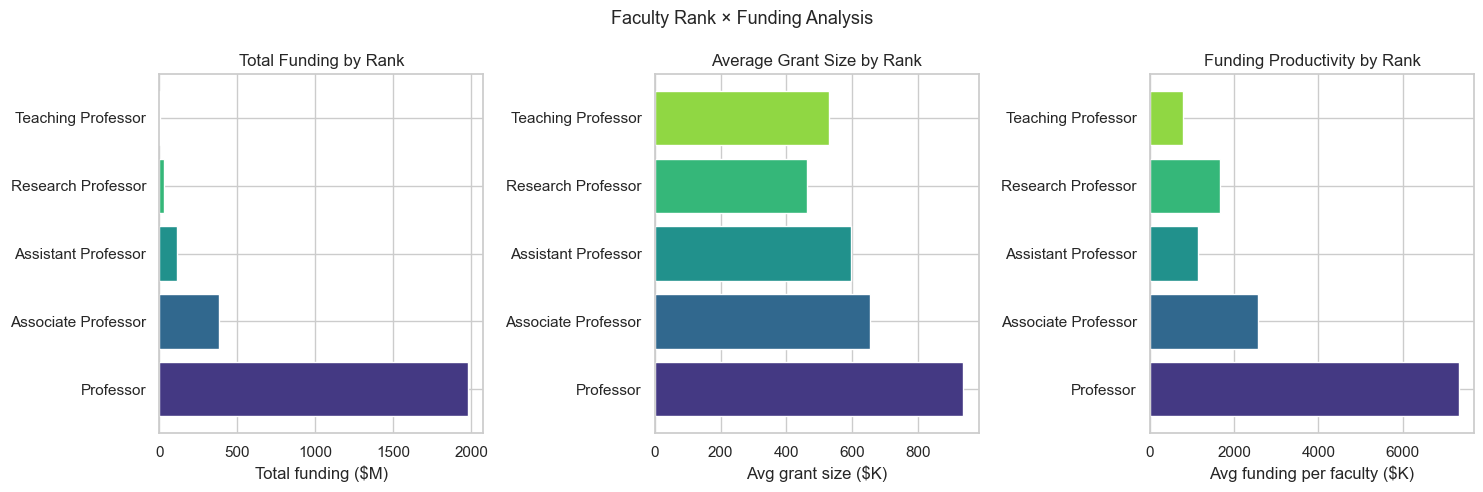

,academic rank,n_faculty,n_grants,total_dollars,mean_grant,median_grant,avg_per_faculty
0,Professor,270,1883,1979159540,937102.054924,429067.0,7.330221e+06
1,Associate Professor,149,556,383919914,654037.332198,440000.0,2.576644e+06
2,Assistant Professor,101,190,115820038,597010.505155,493565.0,1.146733e+06
3,Research Professor,18,65,29980323,461235.738462,351765.0,1.665574e+06
4,Teaching Professor,4,6,3174117,529019.500000,398892.5,7.935292e+05


In [10]:
# Deduplicate: one row per grant per faculty member
gf_dedup = gf_full.drop_duplicates(subset=['grantid', 'clientfacultyid'])

rank_funding = (gf_dedup
                .dropna(subset=['academic rank'])
                .groupby('academic rank', observed=True)
                .agg(
                    n_faculty=('clientfacultyid', 'nunique'),
                    n_grants=('grantid', 'nunique'),
                    total_dollars=('totaldollars', 'sum'),
                    mean_grant=('totaldollars', 'mean'),
                    median_grant=('totaldollars', 'median'),
                )
                .sort_values('total_dollars', ascending=False)
                .reset_index())

rank_funding['avg_per_faculty'] = rank_funding['total_dollars'] / rank_funding['n_faculty']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = sns.color_palette('viridis', len(rank_funding))

axes[0].barh(rank_funding['academic rank'], rank_funding['total_dollars'] / 1e6,
             color=colors)
axes[0].set_xlabel('Total funding ($M)')
axes[0].set_title('Total Funding by Rank')

axes[1].barh(rank_funding['academic rank'], rank_funding['mean_grant'] / 1e3,
             color=colors)
axes[1].set_xlabel('Avg grant size ($K)')
axes[1].set_title('Average Grant Size by Rank')

axes[2].barh(rank_funding['academic rank'], rank_funding['avg_per_faculty'] / 1e3,
             color=colors)
axes[2].set_xlabel('Avg funding per faculty ($K)')
axes[2].set_title('Funding Productivity by Rank')

plt.suptitle('Faculty Rank × Funding Analysis', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'w6_rank_funding.png', dpi=150, bbox_inches='tight')
plt.show()
display(rank_funding)

## 3 · Top-N Faculty by Total Funding

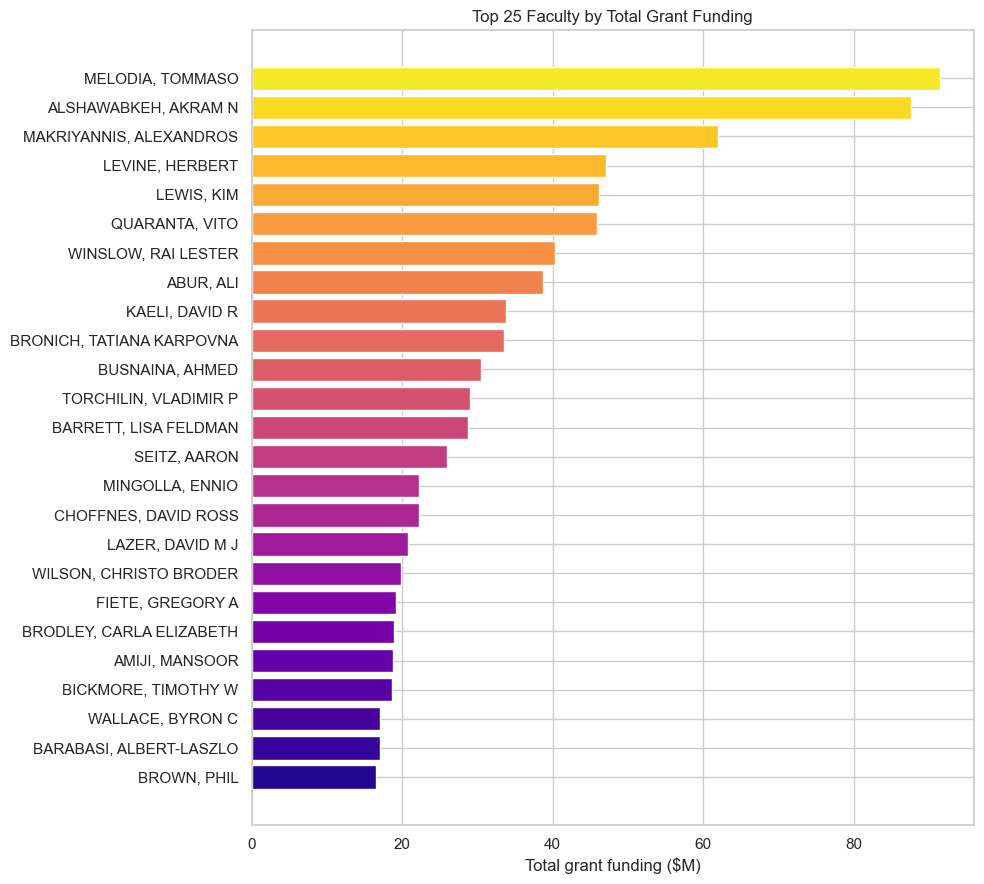

,personname,superior_academic_unit,total_dollars,n_grants,n_as_copi,first_year,last_year
0,"MELODIA, TOMMASO",College of Engineering,91387201,40,13,2010,2025
1,"ALSHAWABKEH, AKRAM N",College of Engineering,87619945,19,5,2001,2020
2,"MAKRIYANNIS, ALEXANDROS",Bouvé College of Health Sciences,61984392,25,2,2004,2022
3,"LEVINE, HERBERT",College of Science,47122908,36,7,2001,2025
4,"LEWIS, KIM",College of Science,46153290,21,1,2004,2022
5,"QUARANTA, VITO",Bouvé College of Health Sciences,45827727,14,1,2004,2018
6,"WINSLOW, RAI LESTER",College of Engineering,40300548,21,3,2005,2020
7,"ABUR, ALI",College of Engineering,38745428,8,1,2005,2024
8,"KAELI, DAVID R",College of Engineering,33796673,33,15,1995,2024
9,"BRONICH, TATIANA KARPOVNA",Bouvé College of Health Sciences,33482077,12,2,2005,2018


In [15]:
top_faculty = (gf_dedup
               .groupby(['clientfacultyid', 'personname', 'superior_academic_unit'], observed=True)
               .agg(
                   total_dollars=('totaldollars', 'sum'),
                   n_grants=('grantid', 'nunique'),
                   n_as_copi=('iscopi', 'sum'),
                   first_year=('startdateyear', 'min'),
                   last_year=('startdateyear', 'max'),
               )
               .sort_values('total_dollars', ascending=False)
               .head(25)
               .reset_index())

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(top_faculty['personname'][::-1],
               top_faculty['total_dollars'][::-1] / 1e6,
               color=sns.color_palette('plasma', len(top_faculty)))
ax.set_xlabel('Total grant funding ($M)')
ax.set_title('Top 25 Faculty by Total Grant Funding')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'w6_top25_faculty_funding.png', dpi=150, bbox_inches='tight')
plt.show()

display(top_faculty[['personname', 'superior_academic_unit',
                      'total_dollars', 'n_grants', 'n_as_copi',
                      'first_year', 'last_year']])

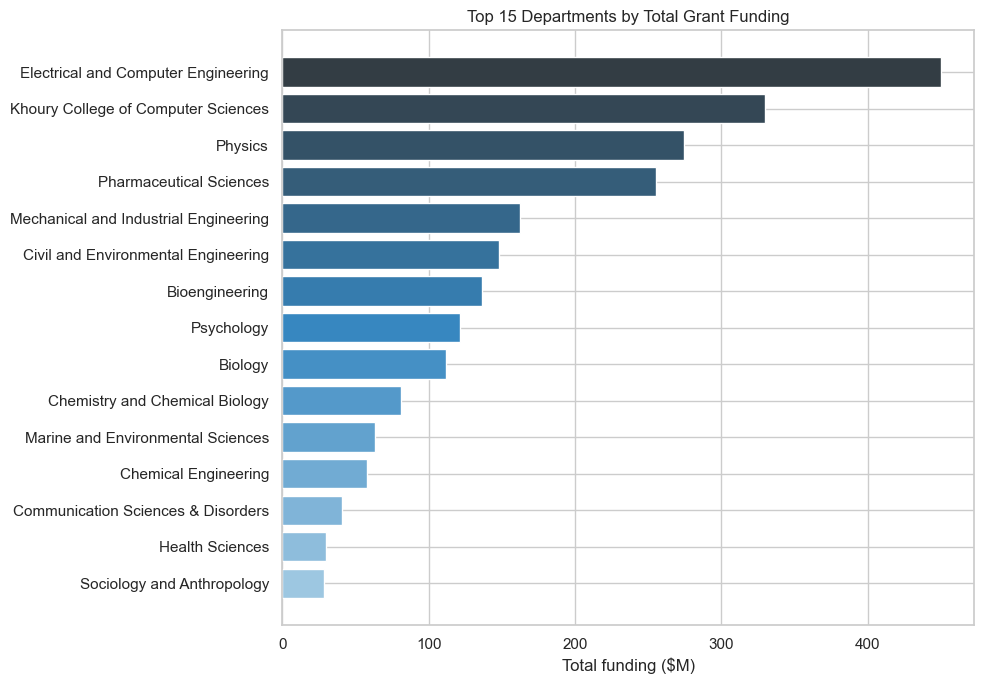

,academic unit,total_dollars,n_grants,n_faculty,avg_per_faculty
0,Electrical and Computer Engineering,450117328,455,63,7.144719e+06
1,Khoury College of Computer Sciences,329848931,380,68,4.850720e+06
2,Physics,274718078,290,43,6.388793e+06
3,Pharmaceutical Sciences,255416573,137,16,1.596354e+07
4,Mechanical and Industrial Engineering,162172640,219,45,3.603836e+06
5,Civil and Environmental Engineering,148322507,125,20,7.416125e+06
6,Bioengineering,136537327,136,25,5.461493e+06
7,Psychology,121605993,103,23,5.287217e+06
8,Biology,111906318,94,18,6.217018e+06
9,Chemistry and Chemical Biology,80971278,100,20,4.048564e+06


In [18]:
# Top 15 departments by total funding
top_depts_funding = (gf_dedup
                     .groupby('academic unit', observed=True)
                     .agg(total_dollars=('totaldollars', 'sum'),
                          n_grants=('grantid', 'nunique'),
                          n_faculty=('clientfacultyid', 'nunique'))
                     .sort_values('total_dollars', ascending=False)
                     .head(15)
                     .reset_index())
top_depts_funding['avg_per_faculty'] = (top_depts_funding['total_dollars'] /
                                         top_depts_funding['n_faculty'])

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_depts_funding['academic unit'][::-1],
        top_depts_funding['total_dollars'][::-1] / 1e6,
        color=sns.color_palette('Blues_d', len(top_depts_funding)))
ax.set_xlabel('Total funding ($M)')
ax.set_title('Top 15 Departments by Total Grant Funding')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'w6_top15_dept_funding.png', dpi=150, bbox_inches='tight')
plt.show()

display(top_depts_funding)

## 4 · Funding Concentration (Gini & Top-10 Share)

Gini coefficient (faculty-level): 0.632
Top 1 faculty share of total funding: 3.4%
Top 10 faculty share of total funding: 19.6%


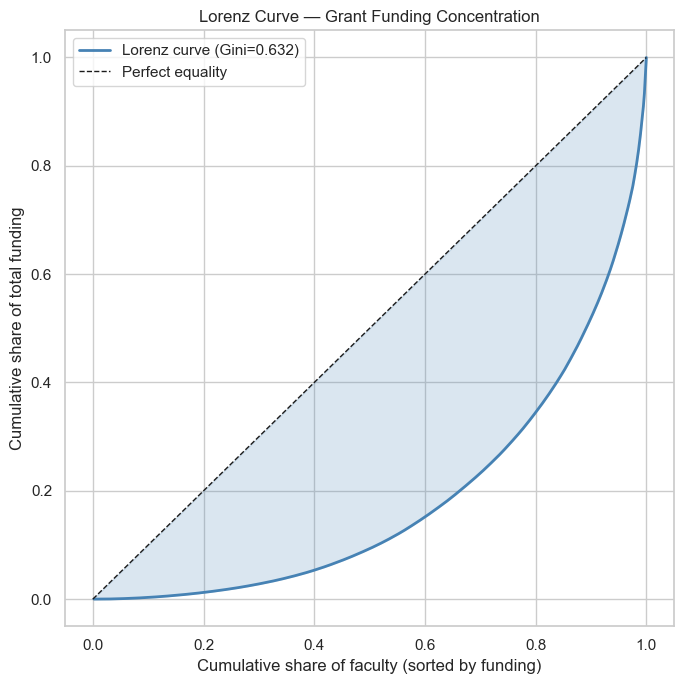

In [20]:
def gini(arr: np.ndarray) -> float:
    """Compute Gini coefficient of a non-negative array."""
    arr = np.sort(arr[arr > 0])
    n = len(arr)
    cumsum = np.cumsum(arr)
    return float((2 * np.sum(np.arange(1, n + 1) * arr) - (n + 1) * cumsum[-1]) /
                 (n * cumsum[-1]))

# Faculty-level total funding
faculty_totals = (gf_dedup
                  .groupby('clientfacultyid')['totaldollars']
                  .sum()
                  .values)

g = gini(faculty_totals)
faculty_totals_sorted = np.sort(faculty_totals[faculty_totals > 0])[::-1]
total_funding = faculty_totals_sorted.sum()
top10_share = faculty_totals_sorted[:10].sum() / total_funding * 100
top1_share  = faculty_totals_sorted[:1].sum() / total_funding * 100

print(f'Gini coefficient (faculty-level): {g:.3f}')
print(f'Top 1 faculty share of total funding: {top1_share:.1f}%')
print(f'Top 10 faculty share of total funding: {top10_share:.1f}%')

# Lorenz curve
sorted_vals = np.sort(faculty_totals[faculty_totals > 0])
cumulative_share = np.cumsum(sorted_vals) / sorted_vals.sum()
population_share = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(population_share, cumulative_share,
        color='steelblue', linewidth=2, label=f'Lorenz curve (Gini={g:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect equality')
ax.fill_between(population_share, cumulative_share, population_share,
                alpha=0.2, color='steelblue')
ax.set_xlabel('Cumulative share of faculty (sorted by funding)')
ax.set_ylabel('Cumulative share of total funding')
ax.set_title('Lorenz Curve — Grant Funding Concentration')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'w6_lorenz_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 · Tenure Status × Agency Funding Cross-Tab

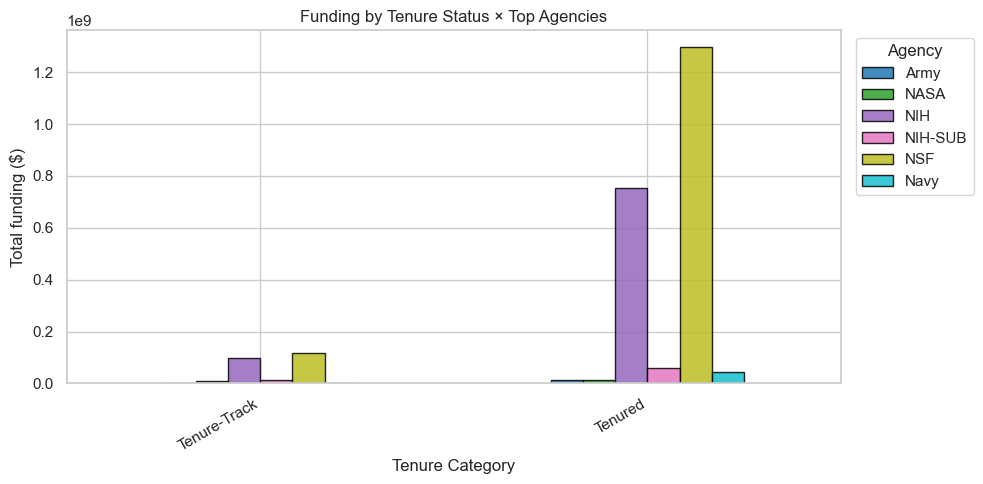

In [22]:
def categorize_tenure(s):
    if pd.isna(s): return 'Non-Tenure Track'
    s = str(s).lower()
    if 'tenured' in s and 'track' not in s: return 'Tenured'
    if 'tenure' in s: return 'Tenure-Track'
    return 'Non-Tenure Track'

gf_dedup = gf_dedup.copy()
gf_dedup['tenure_cat'] = gf_dedup['tenure status'].apply(categorize_tenure)

tenure_agency = (gf_dedup[gf_dedup[a_col].isin(top_agencies)]
                 .groupby(['tenure_cat', a_col], observed=True)
                 ['totaldollars']
                 .sum()
                 .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(10, 5))
tenure_agency.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='black', alpha=0.85)
ax.set_xlabel('Tenure Category')
ax.set_ylabel('Total funding ($)')
ax.set_title('Funding by Tenure Status × Top Agencies')
ax.legend(title='Agency', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'w6_tenure_agency_crosstab.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 · Candidate Headline Findings

Fill in after running all cells:

- **Finding 1 — Funding concentration:** Gini ≈ 0.632 — top 10 faculty account for 19.6% of all dollars
- **Finding 2 — Agency dominance:** NSF + NIH account for >95% of grants; other agencies largely absent
- **Finding 3 — Department leaders:** 
    - MELODIA, TOMMASO	College of Engineering
    - MAKRIYANNIS, ALEXANDROS	Bouvé College of Health Sciences
    - LEVINE, HERBERT	College of Science
    - BARRETT, LISA FELDMAN	College of Science
    - CHOFFNES, DAVID ROSS	Khoury College of Computer Sciences
    - LAZER, DAVID M J	College of Social Sciences and Humanities

In [23]:
# Export summary tables for Week 9 synthesis
top_faculty.to_csv(OUTPUTS_DIR / 'top_faculty_funding.csv', index=False)
top_depts_funding.to_csv(OUTPUTS_DIR / 'top_dept_funding.csv', index=False)
print('Saved summary CSVs.')

Saved summary CSVs.
